# (Linear) Support Vector Regression (SVR)

SVR is a type of support vector machine (SVM) that is used for regression tasks. It tries to find a function that best predicts the continuous output value for a given input value.

An SVM is a supervised machine learning algorithm used for classification and regression tasks. It aims to maximize the margin (the distance between the hyperplane and the nearest data points of each class) while minimizing classification errors. It’s widely used in tasks such as image classification, text categorization, and more.

In SVR, the goal is finding the best fit that accurately predicts the target variable while reducing complexity to avoid overfitting. 

SVR introduces the $ε$-insensitive loss function, which means that errors within a certain threshold (ε) are considered acceptable and do not incur any penalty. Only errors exceeding this threshold contribute to the loss, promoting a balance between model complexity and error minimization.

Some applications of SVR include:

- Financial Forecasting: Predicting stock prices, market trends, or economic indicators.
- Engineering: Modeling and predicting system behaviors, load forecasting, and signal processing.
- Environmental Science: Predicting weather patterns, pollution levels, or resource consumption.
- Bioinformatics: Gene expression analysis, protein structure prediction



### Concept (linear SVR)

*Note: the data isn't accurate, it's just a plot to help understanding the concept.*

- $ε$-insensitive tube / ($w$) hyperplane: it's the margin of error we're allowing in our predictions. 
    - Any prediction *within* this tube is considered acceptable. Predictions *outside* this tube are penalized
- Slack variables: these are the points that fall outside the $ε$-insensitive tube.
- $\xi$: is the distance between the prediction and the $ε$-insensitive tube (noted as $\xi_n^*$ if they are outiside the lower bound, and $\xi_n$ if they are outside the upper bound).

$$\frac{1}{2} ||w||^2 + C \sum_{n=1}^{N} (\xi_n + \xi_n^*)$$


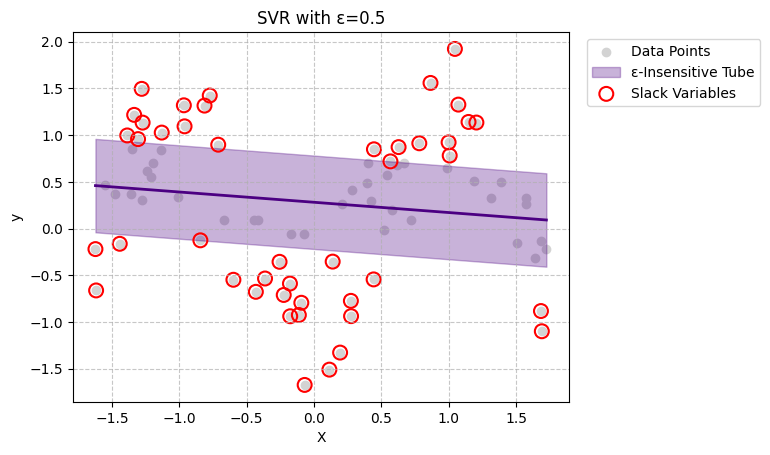

In [25]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# Sample data (assuming X and y are defined)
np.random.seed(0)
X = np.sort(np.random.rand(80, 1) * 10, axis=0)
y = np.sin(X).ravel() + np.random.randn(80) * 0.5

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Define a function to fit and plot SVR models
def plot_svr(X, y, epsilon, color, title):
    svr = SVR(kernel='linear', C=100, epsilon=epsilon)
    svr.fit(X, y)
    y_pred = svr.predict(X)
    diff = np.abs(y - y_pred)
    support_vector_indices = np.where(diff >= svr.epsilon)[0]
    X_sv = X[support_vector_indices]
    y_sv = y[support_vector_indices]

    plt.scatter(X, y, color='lightgray', label='Data Points')
    plt.plot(
        X, y_pred, 
        color=color, linewidth=2, 
        #label=f'SVR Prediction (ε={epsilon})'
        )
    plt.fill_between(
        X.ravel(),
        y_pred - svr.epsilon,
        y_pred + svr.epsilon,
        color=color,
        alpha=0.3,
        label=f'ε-Insensitive Tube'
    )
    plt.scatter(
        X_sv, y_sv,
        facecolors='none',
        edgecolors='red',
        s=100,
        linewidth=1.5,
        label=r'Slack Variables'
    )
    plt.xlabel('X')
    plt.ylabel('y')
    plt.title(title)
    plt.legend(loc='upper right', bbox_to_anchor=(1.4, 1))
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

# Plot for epsilon=0.5
plot_svr(X_scaled, y, epsilon=0.5, color='indigo', title='SVR with ε=0.5')


## Linear SVR with Python

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [27]:
dataset = pd.read_csv('./data/Position_Salaries.csv')
X = dataset.iloc[:, 1:-1].values
y = dataset.iloc[:, -1].values

In [28]:
X

array([[ 1],
       [ 2],
       [ 3],
       [ 4],
       [ 5],
       [ 6],
       [ 7],
       [ 8],
       [ 9],
       [10]])

In [29]:
y

array([  45000,   50000,   60000,   80000,  110000,  150000,  200000,
        300000,  500000, 1000000])

The `StandardScaler` expects a 2D array, so we need to reshape the one-dimensional array `y`: 

In [30]:
y = y.reshape(len(y), 1)

In [31]:
y

array([[  45000],
       [  50000],
       [  60000],
       [  80000],
       [ 110000],
       [ 150000],
       [ 200000],
       [ 300000],
       [ 500000],
       [1000000]])

With SVR, we need to apply feature scaling because it doesn't have an implicit relation between the features and the target variable.

Additionally, the model will not be split into training and testing sets.

In this case: the values of x are much smaller than the values of y and this may cause the model to ignore the x values.

In [32]:
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
sc_y = StandardScaler()
X = sc_X.fit_transform(X)
y = sc_y.fit_transform(y)

In [33]:
X

array([[-1.5666989 ],
       [-1.21854359],
       [-0.87038828],
       [-0.52223297],
       [-0.17407766],
       [ 0.17407766],
       [ 0.52223297],
       [ 0.87038828],
       [ 1.21854359],
       [ 1.5666989 ]])

In [34]:
y

array([[-0.72004253],
       [-0.70243757],
       [-0.66722767],
       [-0.59680786],
       [-0.49117815],
       [-0.35033854],
       [-0.17428902],
       [ 0.17781001],
       [ 0.88200808],
       [ 2.64250325]])

Now we can train the SVR model.

sklearn will throw an error

In [35]:
from sklearn.svm import SVR
regressor = SVR(kernel='rbf')
regressor.fit(X,y.ravel())

SVR()

Predicting a new result:

In [36]:
sc_y.inverse_transform(regressor.predict(sc_X.transform([[6.5]])).reshape(-1,1))

array([[170370.0204065]])

Plotting the results:

For the dots representing the data points:
- Convert the scaled `x` and `y` values back to their original values using the `inverse_transform` method `sc_x.inverse_transform(x), sc_y.inverse_transform(y)`

For the line:
- Same as above for `x`, but for `y`, we need to predict the values using the `regressor.predict(x)` method and reshape the array to a 2D array using `reshape(-1,1)`.

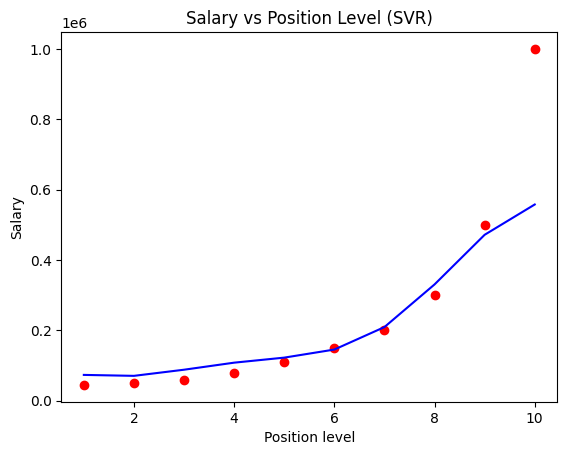

In [37]:
plt.scatter(sc_X.inverse_transform(X), sc_y.inverse_transform(y), color = 'red')
plt.plot(sc_X.inverse_transform(X), sc_y.inverse_transform(regressor.predict(X).reshape(-1,1)), color = 'blue')
plt.title('Salary vs Position Level (SVR)')
plt.xlabel('Position level')
plt.ylabel('Salary')
plt.show()

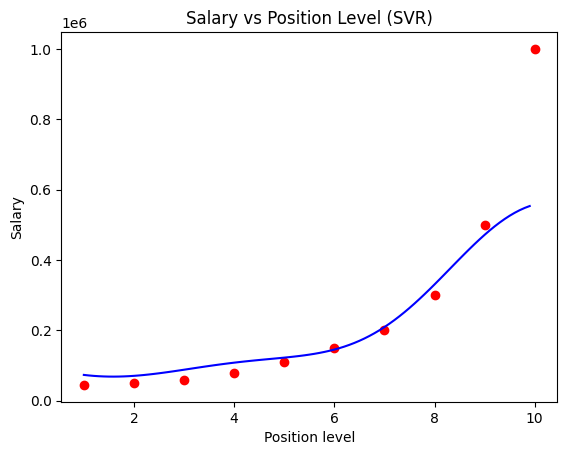

In [38]:
X_grid = np.arange(min(sc_X.inverse_transform(X))[0], max(sc_X.inverse_transform(X))[-1], 0.1)
X_grid = X_grid.reshape((len(X_grid), 1))
plt.scatter(sc_X.inverse_transform(X), sc_y.inverse_transform(y), color = 'red')
plt.plot(X_grid, sc_y.inverse_transform(regressor.predict(sc_X.transform(X_grid)).reshape(-1,1)), color = 'blue')
plt.title('Salary vs Position Level (SVR)')
plt.xlabel('Position level')
plt.ylabel('Salary')
plt.show()